# Clothing Size Recommendation Advice System


## 1. Introduction & Problem Statement

### Introduction
With the rapid growth of online shopping, selecting the correct clothing size has become a major challenge for consumers. Unlike physical stores, online platforms do not allow customers to try garments before purchasing, which often leads to incorrect size selection, dissatisfaction, and high return rates. These issues negatively impact user experience, increase operational costs for retailers, and contribute to environmental waste due to excessive shipping and returns.

Advances in machine learning provide an opportunity to address this problem by analyzing user attributes and historical feedback to generate personalized size recommendations. By learning patterns from previous customers’ body measurements, product characteristics, and fit feedback, an intelligent advice system can assist users in choosing the most appropriate clothing size with higher confidence and accuracy.

### Problem Statement
The goal of this project is to build a **supervised machine learning–based advice system** that recommends an appropriate clothing size based on user and product attributes. Given structured input features such as body measurements, garment type, brand, and customer fit feedback, the system aims to classify whether a recommended size will result in a **good fit**, **tight fit**, or **loose fit**.

This problem is formulated as a **multi-class classification task**, where the target variable represents the perceived fit of a clothing item. The system will serve as a decision-support tool that enhances the online shopping experience by reducing size-related uncertainty and minimizing product returns. In Phase 1, the focus is on understanding the problem domain, exploring the dataset, preprocessing the data, and developing supervised learning models to form a reliable foundation for future enhancements in Phase 2.



## 2. Dataset Selection & Justification

### Dataset Goal & Source
To support the development of the clothing size recommendation system, we selected the **Clothing Fit Dataset for Size Recommendation**, which is publicly available on **Kaggle**.

**Dataset URL:**  
https://www.kaggle.com/datasets/rmisra/clothing-fit-dataset-for-size-recommendation

The primary goal of this dataset is to capture real customer experiences with clothing fit in online shopping contexts. It contains user-provided information and feedback that can be leveraged to predict whether a selected clothing size fits well.

### Dataset Description
The dataset consists of several hundred thousand records and includes structured, tabular data suitable for supervised learning. Key attributes include:

- User characteristics (e.g., height, weight, age)
- Product-related features (e.g., clothing category, brand)
- Size information selected by the customer
- Customer feedback indicating perceived fit (e.g., fit, small, large)

The target variable represents the fit outcome, which aligns directly with the classification objective of this project.

### Justification for Dataset Selection
This dataset was selected for the following reasons:

**1. Relevance to the Problem Domain**  
The dataset directly addresses the challenge of clothing size recommendation by linking user attributes and product information to fit outcomes. This makes it highly suitable for building an advice system focused on fashion and lifestyle guidance.

**2. Sufficient Size and Feature Complexity**  
The dataset contains a large number of observations and more than the minimum required number of features (10–15), ensuring adequate complexity for meaningful exploratory data analysis and model training.

**3. Structured and Cleanable Format**  
The data is provided in a structured, tabular format, making it compatible with Python-based data analysis and machine learning libraries. While preprocessing is required (e.g., handling missing values and encoding categorical variables), the dataset is well-suited for systematic cleaning and feature engineering.

**4. Clear Classification Labels**  
The presence of multiple fit categories enables the formulation of a multi-class classification problem, which satisfies the project requirement of having at least two classes and allows for richer evaluation and comparison of supervised learning algorithms.

**5. Real-World Applicability**  
Because the data is derived from real customer feedback, the resulting model has strong practical relevance and can be extended in Phase 2 to incorporate clustering and Generative AI for personalized explanations and recommendations.



## 3. Data inspection and Exploratory Data Analysis (EDA)



In [36]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [37]:
df = pd.read_csv(
    r'modcloth_final_data.csv',
    low_memory=False
)
df.shape

(82790, 18)

### 3.1 Dataset Overview

The dataset contains 192,544 observations and 15 features. This provides a sufficiently large dataset for building a multi-class classification model.

The target variable is **fit**, which contains three categories:
- fit
- small
- large

The dataset includes a mix of numerical and categorical variables:

- User-related features: height, weight, age, bust size, body type
- Product-related features: category, size, rented for
- Review-related features: rating, review_text, review_summary
- Identifier columns: user_id, item_id


### 3.2 Statistical Summary of Numerical Features

The statistical summary of the ModCloth dataset provides insights into the body measurements and feedback of customers, which are essential for building a reliable advice system:

- **Bra Size:** This numerical feature represents a key body measurement of the customer. The distribution of bra sizes helps the system understand different body types to provide better fitting advice.
- **Quality (Rating):** This column serves as the user's rating for the item. With an average quality score, we can identify which items meet customer expectations and how quality correlates with fit.
- **Shoe Size:** Another physical attribute that adds more depth to the user's profile, allowing the advice system to use multiple physical features for classification.
- **Size:** This is the standard clothing size (ranging from 0 to 58). The high variation in size indicates that the dataset is comprehensive and covers a diverse range of customer segments.

In [38]:
summary_cols = ['bra size', 'quality', 'shoe size', 'size']
available_summary = [col for col in summary_cols if col in df.columns]

summary = df[available_summary].describe()
print(summary)

           bra size       quality     shoe size          size
count  76772.000000  82722.000000  27915.000000  82790.000000
mean      35.972125      3.949058      8.145818     12.661602
std        3.224907      0.992783      1.336109      8.271952
min       28.000000      1.000000      5.000000      0.000000
25%       34.000000      3.000000      7.000000      8.000000
50%       36.000000      4.000000      8.000000     12.000000
75%       38.000000      5.000000      9.000000     15.000000
max       48.000000      5.000000     38.000000     38.000000


### 3.3 Outlier Discussion

Based on the initial inspection of the ModCloth dataset, several numerical features contain extreme or unrealistic values that require attention:

- **Height:** Some entries show unrealistic heights (e.g., very low values like 4'0" or extremely high values converted to inches), which suggests potential data entry errors or inconsistent units.
- **Shoe Size:** The shoe size feature contains extreme values (e.g., values as low as 5 or as high as 38) that may not represent standard sizing, possibly due to a mix of different international sizing scales.
- **Size:** Clothing sizes range up to 58. While this may represent plus-size categories, the extreme end of the distribution could influence model performance and may require filtering during the preprocessing phase.

These outliers are critical to address because they can skew the analysis of the "Fashion Advice System" and lead to inaccurate size recommendations.

In [39]:
# Check for outliers in physical measurements
outlier_check = df[['bra size', 'height', 'shoe size', 'size']].agg(['min', 'max'])
print("Outlier Evidence (Min/Max Values):")
print(outlier_check)

Outlier Evidence (Min/Max Values):
     bra size   height  shoe size  size
min      28.0      3ft        5.0     0
max      48.0  7ft 7in       38.0    38


### 3.4 Target Variable Distribution

The majority of observations are labeled as "fit" (approximately 73.8%), while "small" and "large" each represent about 13–14% of the dataset.

This indicates moderate class imbalance. Although the imbalance is not extreme, evaluation metrics such as precision, recall, and F1-score will be important when assessing model performance.


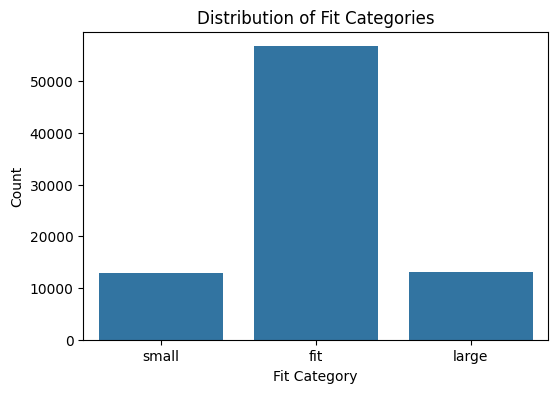

In [40]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.countplot(x='fit', data=df)
plt.title("Distribution of Fit Categories")
plt.xlabel("Fit Category")
plt.ylabel("Count")
plt.show()


### 3.5 Missing Value Analysis

Several body-related attributes contain missing values, particularly:

- weight
- bust size
- body type
- age
- height

Since these features are likely important for predicting clothing fit, appropriate preprocessing strategies such as imputation or filtering will be necessary.

The target variable does not contain missing values, which is beneficial for supervised learning.


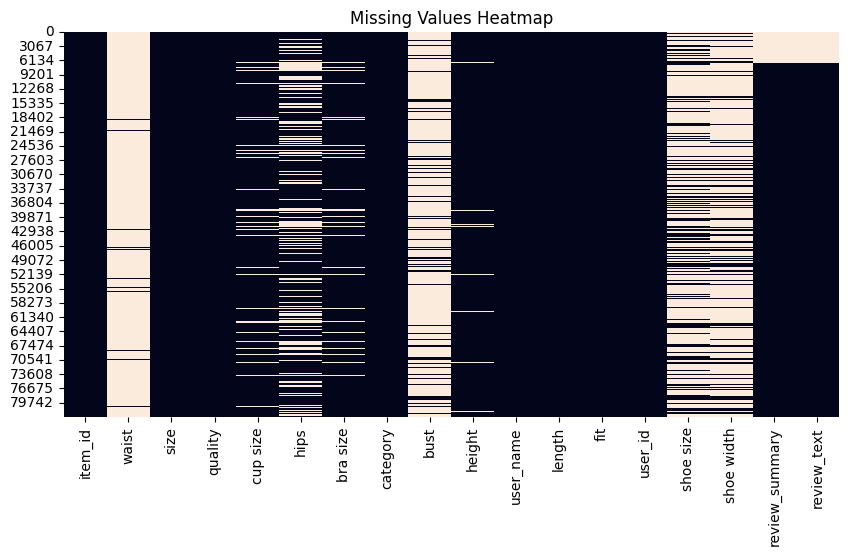

In [41]:
plt.figure(figsize=(10,5))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values Heatmap")
plt.show()


### 3.6 Relationship Between Clothing Size and Fit

The boxplot shows noticeable variation in clothing size across fit categories. This suggests that the selected size plays an important role in determining whether an item fits properly.

This feature is likely to be one of the strongest predictors in the final model.


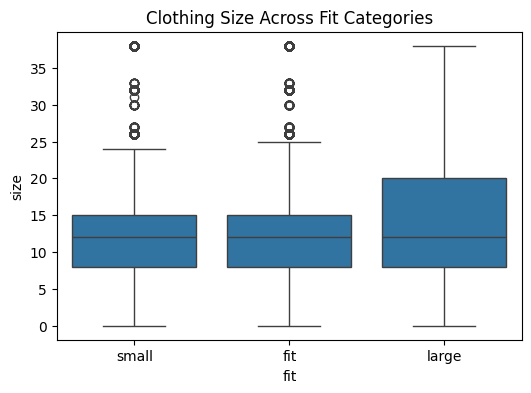

In [42]:
plt.figure(figsize=(6,4))
sns.boxplot(x='fit', y='size', data=df)
plt.title("Clothing Size Across Fit Categories")
plt.show()


### 3.7 Relationship Between Bra Size and Fit

The distribution of bra sizes appears relatively consistent across the three fit categories (Small, Fit, Large). This suggests that while physical measurements like bra size are essential indicators, a single measurement alone may not strongly determine the final clothing fit. Instead, the fit is likely influenced by a combination of multiple body features (such as height, waist, and hips) along with the specific garment's dimensions.

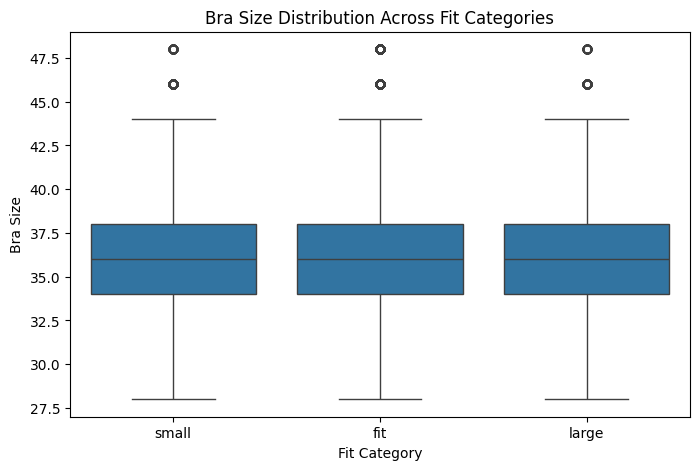

In [43]:
plt.figure(figsize=(8,5))

sns.boxplot(x='fit', y='bra size', data=df)

plt.title("Bra Size Distribution Across Fit Categories")
plt.xlabel("Fit Category")
plt.ylabel("Bra Size")
plt.show()

### 3.8 Relationship Between Quality and Fit

The relationship between product quality and fit provides insights into customer satisfaction. Higher quality scores are more frequently associated with items labeled as "fit," whereas items categorized as "small" or "large" often receive lower quality ratings. This suggests that the perceived quality of a garment is significantly influenced by how well it fits the customer's body.

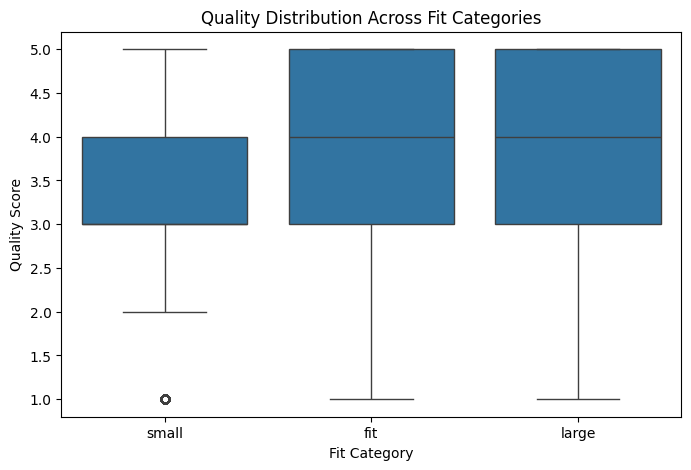

In [44]:
plt.figure(figsize=(8,5))

sns.boxplot(x='fit', y='quality', data=df)

plt.title("Quality Distribution Across Fit Categories")
plt.xlabel("Fit Category")
plt.ylabel("Quality Score")
plt.show()

### 3.9 Correlation Analysis

The correlation matrix provides a statistical overview of how numerical features in the ModCloth dataset relate to one another:

- **Size and Physical Measurements:** There is a moderate positive correlation between `size` and `bra size`. This is expected as larger body measurements generally necessitate larger clothing sizes, which validates the data's consistency.
- **Quality and Other Features:** The `quality` variable (customer rating) shows very weak correlation with physical measurements, suggesting that a customer's satisfaction with an item's quality is independent of their body size.
- **Multicollinearity:** No strong multicollinearity (correlation > 0.8) is observed between the independent variables at this stage. This is beneficial for our future classification models as it reduces redundancy.
- **Feature Engineering Potential:** While individual correlations are moderate, the interaction between features like `height`, `cup size`, and `waist` may reveal stronger predictive power for the "fit" outcome during the preprocessing phase.

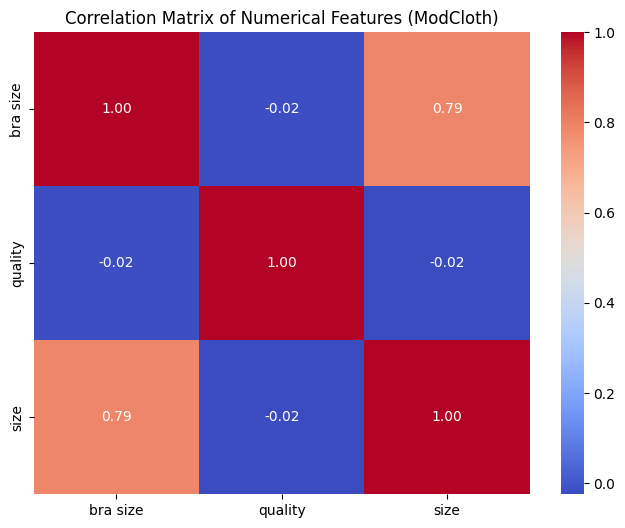

In [ ]:
plt.figure(figsize=(8,6))


corr_features = ['bra size', 'quality', 'size']

sns.heatmap(df[corr_features].corr(), annot=True, cmap='coolwarm', fmt=".2f")

plt.title("Correlation Matrix of Numerical Features (ModCloth)")
plt.show()

### 3.10 Key Insights from EDA

From the exploratory analysis, several important conclusions can be drawn:

- The dataset is large and suitable for supervised machine learning.
- The target variable is moderately imbalanced but manageable.
- Clothing size shows a clear relationship with fit outcome.
- Body-related attributes are likely important predictors but contain missing values.
- Some numerical features contain extreme values and may require cleaning.
- Category and product type may also influence fit perception.

Overall, this analysis helped identify which features are most relevant for predicting clothing fit and provided direction for the preprocessing and modeling stages of the project.
